# ESM-Tools SimCat Examples

This notebook provides end-user examples of how the simulation catalog should work. If run on `albedo`, the experiment paths work.

A traditional workflow is shown below. The scientist would need to know the full paths to all of the experiments they might be interested in:

In [1]:
import pathlib
import xarray as xr
import pyfesom2 as pf2

EXPERIMENTS = {
"basic-001": pathlib.Path("/albedo/work/user/pgierz/SciComp/Tutorials/AWIESM_Basics/experiments/basic-001"), 
"basic-002": pathlib.Path("/albedo/work/user/pgierz/SciComp/Tutorials/AWIESM_Basics/experiments/basic-002"),
"branchoff-002": pathlib.Path("/albedo/work/user/pgierz/SciComp/Tutorials/AWIESM_Basics/experiments/branchoff-002"),
}
list(EXPERIMENTS)

ERROR 1: PROJ: proj_create_from_database: Open of /albedo/soft/sw/conda-sw/analysis-toolbox/07.2024/share/proj failed
/albedo/soft/sw/conda-sw/analysis-toolbox/07.2024/lib/python3.9/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/albedo/soft/sw/conda-sw/analysis-toolbox/07.2024/lib/python3.9/site-packages/pyfesom2/climatology.py:14: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


['basic-001', 'basic-002', 'branchoff-002']

In [2]:
FESOM_DS = {expid: xr.open_mfdataset(f"{exp_path}/outdata/fesom/*nc") for expid, exp_path in EXPERIMENTS.items()}
list(FESOM_DS)

['basic-001', 'basic-002', 'branchoff-002']

FESOM is unstructured, so we need to also load the mesh. Again, this information needs you to know about the file paths. We get a little bit of help since it is encoded directly as an attribute of the NetCDF outdata:

In [3]:
FESOM_DS['basic-001'].FESOM_MeshPath

'/albedo/pool/FESOM2/core2/'

In [4]:
mesh = pf2.load_mesh(FESOM_DS['basic-001'].FESOM_MeshPath)

/albedo/pool/FESOM2/core2/pickle_mesh_py3_fesom2
The usepickle == True)
The pickle file for FESOM2 exists.
The mesh will be loaded from /albedo/pool/FESOM2/core2/pickle_mesh_py3_fesom2


For a very quick plot, we can just do a scatter plot (`lon`, `lat`, `data`). First lets meld together the mesh and the dataset:

In [5]:
FESOM_DS_WITH_MESH = {expid: ds.assign_coords(nod2=range(1, mesh.n2d+1), lat=("nod2", mesh.y2), lon=("nod2", mesh.x2)) for expid, ds in FESOM_DS.items()}

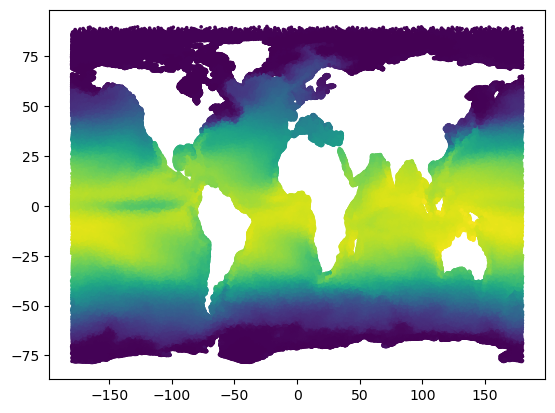

In [6]:
import matplotlib.pyplot as plt
ds = FESOM_DS_WITH_MESH['basic-001']
sst_mean = ds['sst'].mean(dim="time").compute()
fig, ax = plt.subplots()
ax.scatter(ds.lon.values, ds.lat.values, c=sst_mean.values, s=2.5)

Not particularly beautiful, but, the idea should be clear. Beautiful plots are a separate topic.

## Using the STAC Reader Utility

Now, we want to replace the loading of the data to instead come from a *STAC Catalog* so that we don't need to care about the paths of the data at all.

In [7]:
del FESOM_DS, FESOM_DS_WITH_MESH
# This would be hosted on some central web place:
catalog_path = "/albedo/work/user/pgierz/SciComp/Projects/esm-tools-plus/wp1-simcat/esm_tools/examples/fesom_stac/stac_catalog/catalog.json"

The `stac_reader` module provides human-friendly functions to load data from STAC catalogs. It automatically uses the xarray metadata encoded in the catalog (engine, open_kwargs, storage_options) so you don't need to worry about whether files are NetCDF or GRIB.

In [8]:
import sys
sys.path.append("../fesom_stac")

from stac_reader import load_collection

In [9]:
# Shhhhh don't be noisy.
import dask

dask.config.set(
    {"array.slicing.split_large_chunks": False}
)


In [10]:
import intake
EXPERIMENTS = intake.open_stac_catalog(catalog_path)

In [11]:
list(EXPERIMENTS)

['basic-001', 'branchoff-002', 'basic-002']

In [12]:
# Using the stac_reader utility - one line to load all FESOM data!
FESOM_DS = {expid: load_collection(EXPERIMENTS[expid]['fesom']) for expid in EXPERIMENTS}

2026-01-20 16:19:37.962 | INFO     | stac_reader:load_collection:41 - Opening 39 files with open_mfdataset
2026-01-20 16:19:38.335 | INFO     | stac_reader:load_collection:41 - Opening 125 files with open_mfdataset
2026-01-20 16:19:39.898 | INFO     | stac_reader:load_collection:41 - Opening 250 files with open_mfdataset


From here on down, everything is exactly the same:

In [13]:
FESOM_DS['basic-001'].FESOM_MeshPath

'/albedo/pool/FESOM2/core2/'

In [14]:
mesh = pf2.load_mesh(FESOM_DS['basic-001'].FESOM_MeshPath)

/albedo/pool/FESOM2/core2/pickle_mesh_py3_fesom2
The usepickle == True)
The pickle file for FESOM2 exists.
The mesh will be loaded from /albedo/pool/FESOM2/core2/pickle_mesh_py3_fesom2


For a very quick plot, we can just do a scatter plot (`lon`, `lat`, `data`). First lets meld together the mesh and the dataset:

In [15]:
FESOM_DS_WITH_MESH = {expid: ds.assign_coords(nod2=range(1, mesh.n2d+1), lat=("nod2", mesh.y2), lon=("nod2", mesh.x2)) for expid, ds in FESOM_DS.items()}

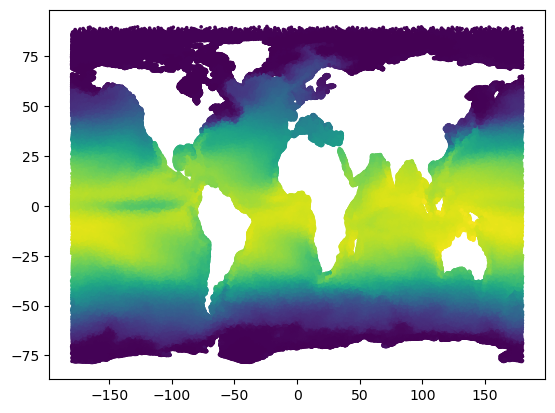

In [16]:
import matplotlib.pyplot as plt
ds = FESOM_DS_WITH_MESH['basic-001']
sst_mean = ds['sst'].mean(dim="time").compute()
fig, ax = plt.subplots()
ax.scatter(ds.lon.values, ds.lat.values, c=sst_mean.values, s=2.5)